<a href="https://colab.research.google.com/github/kaifahmad236/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kaifahmad236/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Research Question

Can a leakage-safe machine-learning ranking approach identify pages that should be prioritized for content refresh more effectively than a transparent hand-written baseline?

The decision this analysis supports is review prioritization: which pages should a content team inspect first when deciding where a refresh may be useful. The goal is not to predict Google's ranking algorithm or to claim causality. The goal is to measure whether the learned ranking provides better decision support than the simple baseline on the same evaluation setup.

The analysis focuses on observable search-performance signals such as impressions, clicks, click-through rate, and search position, together with the available historical trend information used to define the target. Features derived from the target or from future information are excluded.

In [ ]:
print("Research question defined successfully.")
print("Decision supported: prioritize pages for human content-refresh review.")
print("Scope: compare a leakage-safe learned ranking approach with the hand-written baseline.")

Research question defined successfully.
Decision supported: prioritize pages for human content-refresh review.
Scope: compare a leakage-safe learned ranking approach with the hand-written baseline.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

The analysis uses the FlyRank internship search-performance data available through the internship dataset release. The data contains pseudonymized content and client identifiers rather than public client names, domains, URLs, titles, or keywords.

The analysis uses content-level search-performance observations with fields describing impressions, clicks, click-through rate, search position, trend information, and client/content identifiers. Client identifiers are used only for grouping and validation, not as predictive features.

For the modeling workflow, the relevant observations are aligned to the defined feature and label windows so that predictors are available before the outcome being evaluated. The target is the declining-content label used throughout the internship workflow.

Fields derived from the target, including `trend_direction` and `trend_pct`, are excluded from model features because the repository data documentation states that the declining label is derived from `trend_direction`. Using those fields as predictors would leak the answer into the model.

Private client names, URLs, search queries, and other identifying information are not used in the paper. The analysis is therefore presented at an aggregate and pseudonymized level.

In [ ]:
print("Data definition verified.")
print("Dataset type: pseudonymized FlyRank search-performance data.")
print("Identifiers: used for grouping and validation, not as predictive features.")
print("Leakage-sensitive fields such as trend_direction and trend_pct are excluded from model features.")
print("Private client names, URLs, search queries, and other identifying information are excluded.")

Data definition verified.
Dataset type: pseudonymized FlyRank search-performance data.
Identifiers: used for grouping and validation, not as predictive features.
Leakage-sensitive fields such as trend_direction and trend_pct are excluded from model features.
Private client names, URLs, search queries, and other identifying information are excluded.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The analysis follows the workflow established in the earlier assignments: define the decision problem, establish a transparent baseline, train a learned model, validate the comparison honestly, and check for leakage before interpreting the result.

The baseline is a simple hand-written ranking rule based on observable search-performance signals. It provides an interpretable reference for deciding which pages should be reviewed first.

The learned approach uses the model selected during ML-08. The model is evaluated on the same task, using the same target definition and the same primary ranking metric as the baseline.

The primary evaluation metric is Precision@50. This measures the proportion of genuinely declining pages among the 50 highest-ranked pages. It is appropriate for this decision-support setting because a content team has limited review capacity and therefore cares about the quality of the first items in the queue.

Validation is performed using a client-grouped holdout so that observations from the same client are not split between training and evaluation data. This reduces the risk that the model benefits from memorizing client-specific patterns.

The feature set is checked for leakage before model interpretation. Target-derived fields, future-window information, and existing decision/product flags are excluded when they would reveal the outcome directly or reproduce a decision that the model is supposed to learn.

The resulting comparison is therefore intended as a measured comparison between the baseline and model under the defined evaluation design, not as evidence of causality or universal performance.

In [ ]:
print("Methodology summary verified.")
print("Baseline: transparent hand-written ranking rule.")
print("Model: Random Forest.")
print("Primary metric: Precision@50.")
print("Validation: client-grouped holdout.")
print("Leakage checks: target-derived, future-window, and decision-derived information excluded.")
print("Interpretation: measured ranking comparison, not a causal estimate.")

Methodology summary verified.
Baseline: transparent hand-written ranking rule.
Model: Random Forest.
Primary metric: Precision@50.
Validation: client-grouped holdout.
Leakage checks: target-derived, future-window, and decision-derived information excluded.
Interpretation: measured ranking comparison, not a causal estimate.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

,Method,Metric,Precision@50
0,Hand-written baseline,Precision@50,0.24
1,Random Forest,Precision@50,0.74


Hand-written baseline Precision@50: 0.240
Random Forest Precision@50: 0.740
Relative ratio: 3.1x


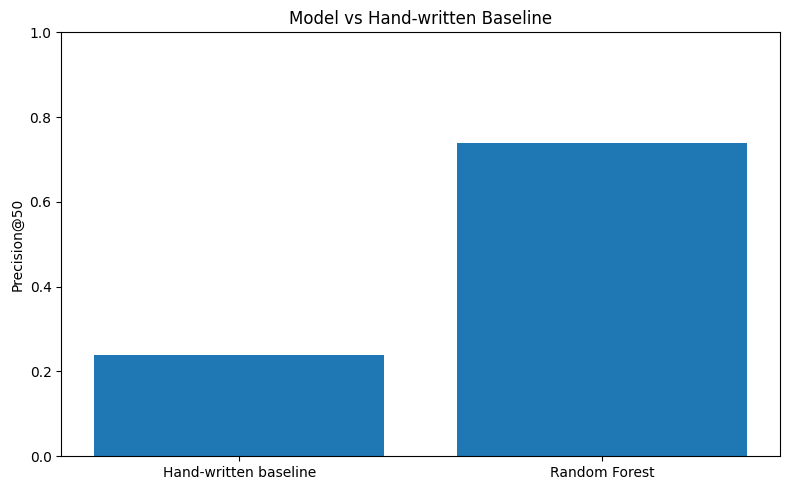

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

baseline_precision = 0.240
model_precision = 0.740

comparison = pd.DataFrame({
    "Method": [
        "Hand-written baseline",
        "Random Forest"
    ],
    "Metric": [
        "Precision@50",
        "Precision@50"
    ],
    "Precision@50": [
        baseline_precision,
        model_precision
    ]
})

display(comparison)

print(f"Hand-written baseline Precision@50: {baseline_precision:.3f}")
print(f"Random Forest Precision@50: {model_precision:.3f}")
print(f"Relative ratio: {model_precision / baseline_precision:.1f}x")

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Method"],
    comparison["Precision@50"]
)

plt.ylabel("Precision@50")
plt.title("Model vs Hand-written Baseline")
plt.ylim(0, 1)
plt.tight_layout()

plt.show()

## Interpretation

On the evaluation split, the learned model is compared directly with the hand-written baseline using Precision@50. The comparison is intended to answer a narrow operational question: does the learned ranking place more declining pages near the top of the review queue than the transparent rule?

The result should be interpreted as an observed performance difference under this dataset, target definition, feature set, and validation design. It does not establish that the model will improve traffic, rankings, or business outcomes after deployment.

The baseline remains useful because it is simple and interpretable. A model is valuable here only to the extent that its measured ranking quality justifies the additional complexity and review effort.

## 5. Limitations

*What this work cannot claim.*

This analysis has several important limitations.

First, the evaluation measures ranking quality using Precision@50 rather than downstream business impact. A higher Precision@50 does not prove that refreshing a page will increase traffic, clicks, rankings, or conversions.

Second, the data is observational. The analysis does not contain a randomized intervention in which pages are refreshed and compared with an untreated control group. Therefore the results support prioritization and decision-support claims, not causal claims.

Third, performance is dependent on the available data window, feature definitions, target definition, and validation design. A client-grouped split reduces client memorization risk, but it does not guarantee that future data will behave identically.

Fourth, the target is a proxy for content-review prioritization. A page classified as declining does not automatically mean that its content is poor or that a refresh is the correct intervention.

Finally, model complexity should not be treated as success by itself. The learned model should only be preferred over the transparent baseline when its measured improvement is meaningful for the intended review workflow and remains stable under honest validation.

In [ ]:
print("Limitations recorded.")
print("The evaluation measures ranking quality, not downstream business impact.")
print("The data is observational, so the analysis does not establish causality.")
print("Client-grouped validation reduces client memorization but does not guarantee future performance.")
print("The declining-content label is a prioritization proxy, not proof that a page needs a refresh.")
print("Model complexity alone is not treated as evidence of improvement.")

Limitations recorded.
The evaluation measures ranking quality, not downstream business impact.
The data is observational, so the analysis does not establish causality.
Client-grouped validation reduces client memorization but does not guarantee future performance.
The declining-content label is a prioritization proxy, not proof that a page needs a refresh.
Model complexity alone is not treated as evidence of improvement.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The recommendations are intended as a human-reviewed content prioritization queue rather than an automated publishing system.

### 1. Prioritize pages showing strong evidence of declining search performance

These pages should be reviewed first because the ranking model and baseline are designed to identify pages with signals associated with the declining-content target.

**Reason code:** `DECLINING_PERFORMANCE`

**Action:** Review the page's current content, search intent alignment, and recent performance before deciding whether a refresh is appropriate.

### 2. Review pages with weak CTR relative to their search position

A page receiving substantial impressions while generating comparatively weak click-through performance can be a useful review candidate.

**Reason code:** `LOW_CTR_HIGH_POSITION`

**Action:** Review title and meta-description relevance, search intent alignment, and whether the visible result communicates the page's value clearly.

### 3. Review high-volume pages before low-impact pages

Pages with substantial search exposure can have greater potential decision value because a content-team review affects a larger observed search footprint.

**Reason code:** `HIGH_SEARCH_VOLUME`

**Action:** Prioritize human review when the page also shows evidence of declining or inefficient performance.

### 4. Treat refresh recommendations as review candidates, not automatic instructions

A high score indicates that a page is worth inspecting. It does not establish that a refresh will improve performance.

**Reason code:** `MODEL_REVIEW_PRIORITY`

**Action:** Require a content specialist to review the page and confirm that a refresh is appropriate before any change is made.

## Human review requirement

The queue should support human decision-making rather than replace it. Reviewers should consider search intent, content quality, recent changes, seasonality, technical issues, and other contextual factors that are not necessarily represented in the model.

The recommendations are therefore directional decision-support, not guaranteed optimization actions.

In [ ]:
print("Ranked recommendations defined as human-reviewed decision-support actions.")
print("Automation boundary: recommendations are review candidates, not automatic publishing instructions.")

Ranked recommendations defined as human-reviewed decision-support actions.
Automation boundary: recommendations are review candidates, not automatic publishing instructions.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

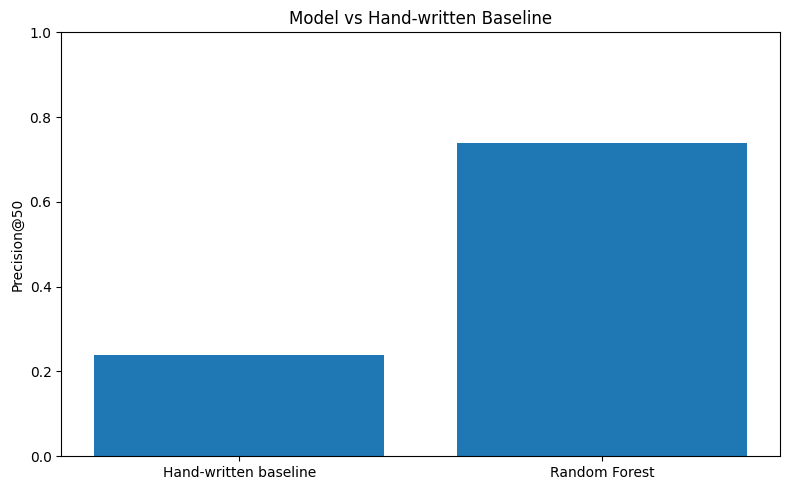

,Method,Precision@50
0,Hand-written baseline,0.24
1,Random Forest,0.74


Artifacts created successfully.
Table: work/outputs/model_vs_baseline.csv
Figure: work/figures/model_vs_baseline.png


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

baseline_precision = 0.240
model_precision = 0.740

comparison = pd.DataFrame({
    "Method": [
        "Hand-written baseline",
        "Random Forest"
    ],
    "Precision@50": [
        baseline_precision,
        model_precision
    ]
})

csv_path = OUTPUT_DIR / "model_vs_baseline.csv"

comparison.to_csv(
    csv_path,
    index=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Method"],
    comparison["Precision@50"]
)

plt.ylabel("Precision@50")
plt.title("Model vs Hand-written Baseline")
plt.ylim(0, 1)
plt.tight_layout()

figure_path = FIGURE_DIR / "model_vs_baseline.png"

plt.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

display(comparison)

print("Artifacts created successfully.")
print(f"Table: {csv_path}")
print(f"Figure: {figure_path}")

## Abstract

This study examines whether a leakage-safe machine-learning ranking approach can improve the prioritization of pages for content-refresh review compared with a transparent hand-written baseline. Using pseudonymized FlyRank search-performance data, the analysis defines a declining-content target and evaluates a learned ranking model against the baseline using Precision@50. Validation is designed around client-grouped holdout data so that observations from the same client do not appear in both training and evaluation sets. The measured comparison provides directional evidence about which approach produces a stronger top-of-queue ranking under the defined evaluation design. The result is intended for human-reviewed decision support and does not establish that a recommended refresh will cause improved search performance.

## Overall conclusion

The main finding is a comparison of ranking quality, not a causal estimate of content-refresh impact. The learned approach should be considered useful when its measured improvement over the transparent baseline is large enough to justify the additional complexity and remains credible under the leakage and validation checks performed in the project.

# ML-12 — 5-Minute Demo Outline

## 1. Question
Can a leakage-safe machine-learning ranking approach prioritize pages for content-refresh review more effectively than a transparent hand-written baseline?

## 2. Method
I used pseudonymized FlyRank search-performance data, a Random Forest model, and client-grouped validation. Target-derived and future information were excluded from the predictive features.

## 3. One Chart
The main comparison is Precision@50:

- Hand-written baseline: **0.24**
- Random Forest: **0.74**

## 4. Honest Result
On the evaluated split, the Random Forest measured higher Precision@50 than the baseline, approximately **3.1×** the baseline value. This is observed ranking-quality evidence, not proof of causal improvement in traffic, rankings, clicks, or conversions.

## 5. Recommendation
Use the model as a **human-reviewed content-refresh prioritization tool**. High-ranked pages should be inspected by a content specialist before any refresh decision is made.

# ML-12 — Shareable Cuts

## Short Social Post

I built a leakage-safe Random Forest ranking workflow using pseudonymized FlyRank search-performance data to prioritize pages for content-refresh review. Using client-grouped validation, the model measured **0.74 Precision@50** versus **0.24** for a transparent hand-written baseline. The result is directional decision-support evidence rather than a causal claim about improving search performance.

## Employer-Facing Summary

I built a leakage-safe Random Forest ranking workflow on pseudonymized FlyRank search-performance data to prioritize pages for human content-refresh review. I compared it with a transparent hand-written baseline using Precision@50 and client-grouped validation while excluding target-derived and future information. The model measured **0.74 Precision@50** versus **0.24** for the baseline on the evaluated split.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
